# Stochastic Processes Homework 2
# Pedro Sáez s5110998

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In Tutorial 7, Exercise 2, we proved that if we have a deck of $n$ cards and at each step we take the top car and place it back uniformly at random in one of the $n$ possible positions, we can model the position of a given card as a Markov chain $(X_t)_{t\ge0}$.

The Markov chain is aperiodic and irreducible, and hence has a unique stationary distribution $\pi$, which is the uniform distribution on $\{1,...,n\}$.

We determined the transition matrix $P$ to be given by:

\begin{equation}
\begin{pmatrix}
\frac{1}{n} & \frac{1}{n} & \frac{1}{n}  & ... & \frac{1}{n} & \frac{1}{n}\\
 1-\frac{1}{n}& \frac{1}{n} & 0 & ... &  0 & 0\\
 0& 1-\frac{2}{n} & \frac{2}{n} & 0 & ... & 0\\
 ⋮& ⋮ & ⋮ & ⋮ & ... & 0 \\
 0& 0 & 0 & 0 & \frac{1}{n} & 1-\frac{1}{n}
\end{pmatrix}
\end{equation}


which can be summarised as:

\begin{equation}
P_{ij} = \left\{ \begin{array}{cl}
\frac{1}{n} & \text{if} \ i=1,\\
1-\frac{i}{n} & \text{if} \ i\neq1, j=i-1,\\
\frac{i-1}{n} & \text{if} \ i\neq1, j=i.
\end{array} \right.
\end{equation}

The idea behind this is that if the chosen card is at the top, then when we place it back uniformly at random every position is equally likely, so the first row has the same probability $\frac{1}{n}$. For $i\neq 1$, when we remove the top card and place it back in the deck at position $j$, we have two options. Either $i> j$ so the chosen card remains at position $i$ (the chosen card does not move), which occurs with probability $\frac{i-1}{n}$ (hence $P_{ii}=\frac{i-1}{n}$). Or, $i< j$ and the chosen card moves one position, with probability $1-\frac{i-1}{n}$. These are the only options, which is why the rest of the entries of $P$ are zero.

In [ ]:
#Value of n
n = 32

#Define the transition matrix as explained above
transition_P = np.zeros((n,n))
transition_P[0] = 1/n
for i in range(1,n):
  index = i
  transition_P[i][i-1] = 1-i/n
  transition_P[i][i] = i/n
print(f"Matrix P = {transition_P}")

#Verify probabiliy rows add up to one (sanity check):
print(f"Sum rows: {np.sum(transition_P,axis=1)}")

Matrix P = [[0.03125 0.03125 0.03125 ... 0.03125 0.03125 0.03125]
 [0.96875 0.03125 0.      ... 0.      0.      0.     ]
 [0.      0.9375  0.0625  ... 0.      0.      0.     ]
 ...
 [0.      0.      0.      ... 0.90625 0.      0.     ]
 [0.      0.      0.      ... 0.0625  0.9375  0.     ]
 [0.      0.      0.      ... 0.      0.03125 0.96875]]
Sum rows: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
#Define initial distributions
X0_1 = np.zeros(n)
X0_2 = np.zeros(n)
X0_3 = np.zeros(n)
pi_vector = np.zeros(n) #pi vector is the stationary distribution

X0_1[0] = 1
X0_2[-1] = 1

for i in range(32):
  X0_3[i] = 1/n
  pi_vector[i] = 1/n

print(f"X0_1 = {X0_1}")
print(f"X0_2 = {X0_2}")
print(f"X0_3 = {X0_3}")

X0_1 = [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]
X0_2 = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 1.]
X0_3 = [0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125
 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125
 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125
 0.03125 0.03125 0.03125 0.03125 0.03125]


In order to perform simulations, we note that for any initial condition $\mu$ the state at time $t$ is given by: $X_t= \mu P^{t}=\mu P^{t-1} P=X_{t-1}P$. Hence we only have to multiply the initial state by $P$ iteratively to obtain the state at future time steps $t$.

In [ ]:
#Perform simulations
#We select a maximum value of t, in this case 1000
values_t = np.arange(1, 1001)
Xt_1 = np.zeros((len(values_t),n))
Xt_2 = np.zeros((len(values_t),n))
Xt_3 = np.zeros((len(values_t),n))

#Set initial conditions
Xt_1[0] = X0_1
Xt_2[0] = X0_2
Xt_3[0] = X0_3

#Perform simulation
#As described above, we multiply iteratively on the right by the
#transition matrix to obtain the state at the next time step
for i in range(1, len(values_t)):
  Xt_1[i] = np.matmul(Xt_1[i-1], transition_P)
  Xt_2[i] = np.matmul(Xt_2[i-1], transition_P)
  Xt_3[i] = np.matmul(Xt_3[i-1], transition_P)


In order to compute the variational distance we use the following lemma from Lecture 6:
\begin{equation}
d_{TV}(X,Y) = \frac{1}{2}\sum_{x\in S}|\mathbb{P}(X=x)-\mathbb{P}(Y=x)|=\frac{1}{2}\sum_{x=0}^{n}|\mathbb{P}(X=x)-\mathbb{P}(Y=x)|
\end{equation}

In [ ]:
#Compute variational distance using equation above
def var_distance(n, X, Y):
  total_dist = 0
  for i in range(n):
    total_dist += np.abs(X[i]-Y[i])
  var_distance = 0.5 * total_dist
  return var_distance

As shown during the tutorial, for $\mu_1=(1,0,0,...,0)$ we get that $\mu_1P = \pi$, with $\pi$ the uniform distribution: $\pi = (\frac{1}{n}, \frac{1}{n},...,\frac{1}{n})$. We also proved that $\mu_1P^2=\pi P = \pi$, i.e. that the uniform distribution $\pi$ is the (unique since irreducible) stationary distribution. Therefore, we get that given the inital condition $X_0=1$ the distribution converges to the stationary distribution in one time step, which is evidenced in the plot below (the variational distance decreases to zero in one time-step).

Moreover, for the third plot, since we are considering the total variational distance between $\mu_3 P^t$ and $\pi$ and $\mu_3=\pi=(\frac{1}{n}, \frac{1}{n},...,\frac{1}{n})$ i.e. it has been shown already to be the stationary distribution, then clearly the distance from the distribution to itself will be zero for any time step, which is why the graph is an horizontal line at $d_{TV}(\mu P^t, \pi)=0$.

Note that we do not get this behaviour for $\mu_2$, but by the Markov Chain convergence theorem, we are assured that $\mu_2P^t$ will converge to $\pi$ exponentially fast, which is clearly seen in the graph: the variational distance decreases exponentially to zero.

/tmp/ipython-input-2403070875.py:21: RuntimeWarning: divide by zero encountered in log
  ax[1].plot(values_t, np.log(dtv_1), label=r"$X_0=1$")
/tmp/ipython-input-2403070875.py:23: RuntimeWarning: divide by zero encountered in log
  ax[1].plot(values_t, np.log(dtv_3), label=r"$X_0=_d$Unif$(1,...,32)$")


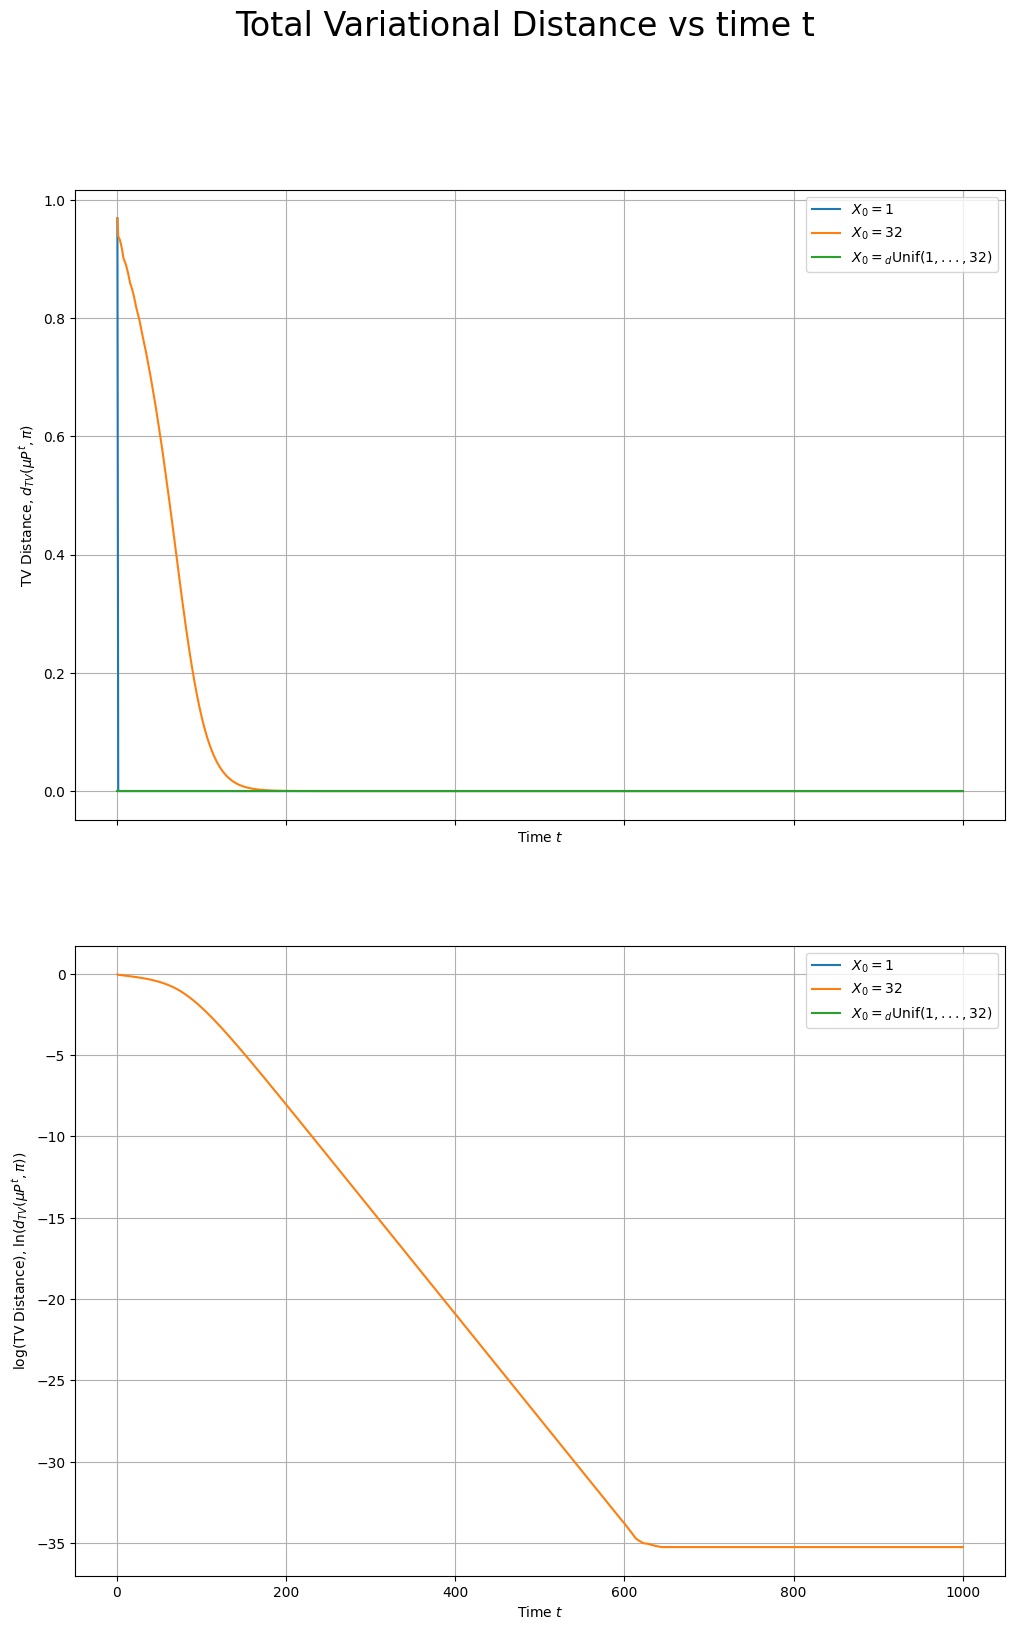

In [ ]:
#Plots to visualize convergence
dtv_1 = np.zeros(len(values_t))
dtv_2 = np.zeros(len(values_t))
dtv_3 = np.zeros(len(values_t))

for i in range(len(values_t)):
  dtv_1[i] = var_distance(n, Xt_1[i], pi_vector)
  dtv_2[i] = var_distance(n, Xt_2[i], pi_vector)
  dtv_3[i] = var_distance(n, Xt_3[i], pi_vector)

fig, ax = plt.subplots(2, 1, figsize=(12, 18), sharex=True)

ax[0].plot(values_t, dtv_1, label=r"$X_0=1$")
ax[0].plot(values_t, dtv_2, label=r"$X_0=32$")
ax[0].plot(values_t, dtv_3, label=r"$X_0=_d$Unif$(1,...,32)$")
ax[0].set_xlabel(r"Time $t$")
ax[0].set_ylabel(r"TV Distance, $d_{TV}(\mu P^t, \pi)$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(values_t, np.log(dtv_1), label=r"$X_0=1$")
ax[1].plot(values_t, np.log(dtv_2), label=r"$X_0=32$")
ax[1].plot(values_t, np.log(dtv_3), label=r"$X_0=_d$Unif$(1,...,32)$")
ax[1].set_xlabel(r"Time $t$")
ax[1].set_ylabel(r"log(TV Distance), $\ln(d_{TV}(\mu P^t, \pi))$")
ax[1].legend()
ax[1].grid(True)


fig.suptitle("Total Variational Distance vs time t", fontsize=24)
plt.show()


The graphs of $X_0=1$ and $X_0=\text{Unif}\{1,...,32\}$ for  $\ln(d_{TV}(\mu P^t, \pi))$ vs $t$ do not display. This is because by the discussion above the distance between the two distributions gets to zero in a small finite time step $t$ (namely $t=1$ for $X_0=1$ and $t=0$ for $X_0=\text{Unif}\{1,...,32\}$ ). Hence when we compute the $\log$ of the graph we get an error, since $\ln(0)$ is undefined.

However, for $X_0=32$ the graph shows a straight line for relatively large values of $t$. This is as expected, since for $t$ sufficiently large we get by the Markov chain convergence theorem that the variational distance decreases exponentially. Assuming that the variational distance matches the upper bound):
\begin{equation}
d_{TV}(\mu P^t, \pi)=\alpha^t⇒\ln(d_{TV}(\mu P^t, \pi))=t\ln(\alpha).
\end{equation}
From this expression we can estimate the value of $0\le\alpha\le1$ by calculating the gradient $m$ of the straight line of $\ln(d_{TV}(\mu P^t, \pi))$ vs $t$ and setting $\alpha=e^m$.

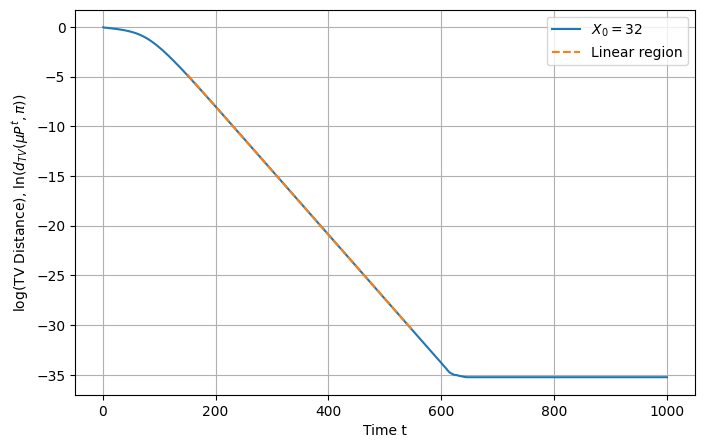

Gradient: -0.06444653015445147
alpha: 0.9375862455135187


In [ ]:
#To compute the gradient of the graph we select the
#linear region of the log graph for X_0 = 32, which is about 150-550.
t_1 = 150
t_2 = 550

#Create a mask to select the time values where the graph is linear
mask = (values_t >= t_1) & (values_t <= t_2)
linear_t = values_t[mask]
linear_ln_dTV2 = np.log(dtv_2[mask])

#Fit linear line to the linear region
slope, intercept = np.polyfit(linear_t, linear_ln_dTV2, 1)



plt.figure(figsize=(8,5))
plt.plot(values_t, np.log(dtv_2), label=r"$X_0=32$")
plt.plot(linear_t, slope*linear_t + intercept, '--', label="Linear region")
plt.xlabel("Time t")
plt.ylabel(r"log(TV Distance), $\ln(d_{TV}(\mu P^t, \pi))$")
plt.legend()
plt.grid(True)
plt.show()

print(f"Gradient: {slope}")
print(f"alpha: {np.exp(slope)}")


Hence the estimated value of $0\le\alpha\le1$ for $X_0=32$ is $\alpha = 0.9376$.